In [1]:
import osmnx as ox
import networkx as nx
import igraph as ig
import pandas as pd
import geopandas as gpd
import time
import matplotlib.pyplot as plt

***

Import Copenhagen street network as example data

In [2]:
# download some random network
G = ox.graph_from_place(
    query="Copenhagen Municipality",
    network_type='all',
    simplify=True, 
    retain_all=False,
    truncate_by_edge=False,
    which_result=None,
    custom_filter=None
)

In [3]:
print("Edges:", len(G.edges))
print("Nodes:", len(G.nodes))

Edges: 119226
Nodes: 44173


In [4]:
nodes, edges = ox.graph_to_gdfs(G, nodes = True, edges = True)

***

select source and target node for example path computation

<Axes: >

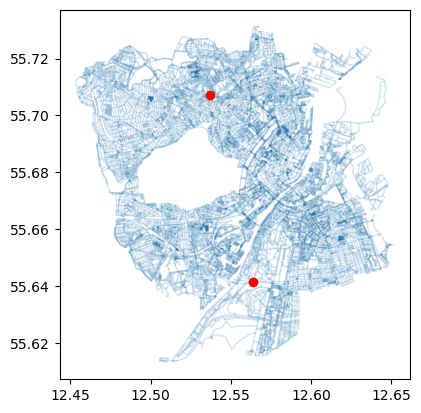

In [5]:
fig, ax = plt.subplots(1,1)
edges.plot(ax=ax, linewidth=1, zorder=0, alpha = 0.1)
nodes.iloc[[25,1225]].plot(ax=ax, color = "red", zorder = 1)

In [6]:
nodes.iloc[[25,1225]]

,y,x,street_count,highway,ref,geometry
osmid,,,,,,
118820,55.641405,12.563551,4,NaN,NaN,POINT (12.56355 55.64140)
8091688,55.707335,12.536868,4,NaN,NaN,POINT (12.53687 55.70734)


In [7]:
# OSMIDS of these nodes are "source" and "target" IDs in networkx
s_nx = 118820
t_nx = 8091688

***

convert to Graph

In [8]:
# convert from MultiDiGraph to Graph
G = nx.Graph(G)

In [9]:
print("Edges:", len(G.edges))
print("Nodes:", len(G.nodes))

Edges: 63894
Nodes: 44173


***

Time shortest path computations for selected source & target with **networkx**

In [10]:
%%timeit
nx.shortest_path(
    G=G,
    source=s_nx,
    target=t_nx
)
# shortest path (unweighted)

46.2 ms ± 5.58 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [11]:
%%timeit
nx.shortest_path(
    G=G,
    source=s_nx,
    target=t_nx,
    weight="length"
)
# shortest path (weighted)

218 ms ± 36.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
%%timeit
i = 0
for path in nx.shortest_simple_paths(
    G=G,
    source=s_nx,
    target=t_nx,
    #weight="length"
):
    #print(len(path))
    i += 1
    if i > 1:
        break
# k shortest paths unweighted, k = 2

3.27 s ± 302 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [14]:
%%timeit
i = 0
for path in nx.shortest_simple_paths(
    G=G,
    source=s_nx,
    target=t_nx,
    weight="length"
):
    #print(len(path))
    i += 1
    if i > 1:
        break
# k shortest paths weighted, k = 2

15.6 s ± 681 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


***

Time shortest path computations for selected source & target with **igraph**

In [15]:
# convert from networkx to igraph
g = ig.Graph.from_networkx(G, vertex_attr_hashable="osmid")
# get corresponding node ids in igraph
s_ig, t_ig = [v.index for v in g.vs.select(osmid_in=[s_nx,t_nx])]

In [16]:
%%timeit
g.get_shortest_path(
    v=s_ig,
    to=t_ig,
    weights=None,
    mode='out',
    output='vpath',
    algorithm='auto'
)
# shortest path (unweighted)
# ~15x faster than nx

2.92 ms ± 297 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [17]:
%%timeit
g.get_shortest_path(
    v=s_ig,
    to=t_ig,
    weights="length",
    mode='out',
    output='vpath',
    algorithm='auto'
)
# shortest path (weighted)
## 6x faster than nx

32.1 ms ± 1.58 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [18]:
%%timeit
l = g.get_k_shortest_paths(
    v=s_ig,
    to=t_ig,
    k = 2,
    #weights="length",
    #mode='out',
    #output="vpath"
)
# k shortest paths (unweighted), k = 2

1.96 s ± 72.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [19]:
%%timeit
l = g.get_k_shortest_paths(
    v=s_ig,
    to=t_ig,
    k = 2,
    weights="length",
    #mode='out',
    #output="vpath"
)
# k shortest paths (weighted), k = 2

2.14 s ± 120 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
